In [10]:
# Install pandas and openpyxl directly in the active notebook environment
!pip install pandas openpyxl

  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl (12.3 MB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/5 [tzdata]
   ---------------------------------------- 0/5 [tzdata]
   ---------------------------------------- 0/5 [tzdata]
   ---------------------------------------- 0/5 [tzdata]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import os

print("Checking files in the directory...")
print("Files found:", os.listdir('.'))

try:
    # 1. Load both CSV datasets
    print("\nLoading Fake.csv...")
    fake_df = pd.read_csv('Fake.csv')
    
    print("Loading True.csv...")
    true_df = pd.read_csv('True.csv')

    # 2. Assign labels: 1 for Fake news, 0 for Real news
    fake_df['label'] = 1
    true_df['label'] = 0

    # 3. Combine them vertically into a single DataFrame
    df = pd.concat([fake_df, true_df], ignore_index=True)

    # 4. Shuffle the rows randomly so the model gets a mixed batch
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print("\n--- SUCCESS: DATASET COMBINED ---")
    print(f"Total rows loaded: {len(df)}")
    print("\n--- DATASET BALANCING ---")
    print(df['label'].value_counts())

    print("\n--- MISSING VALUE CHECK ---")
    print(df.isnull().sum())

    print("\n--- SAMPLE DATA ---")
    display(df.head())

except FileNotFoundError as e:
    print("\n❌ FILE NOT FOUND ERROR:")
    print(f"Could not find the file: {e.filename}")
    print("Please verify that both 'Fake.csv' and 'True.csv' are spelled exactly right and placed directly in your project folder.")
except Exception as e:
    print(f"\n❌ AN ERROR OCCURRED: {e}")

Checking files in the directory...
Files found: ['.venv', 'Fake.csv', 'main.ipynb', 'True.csv']

Loading Fake.csv...
Loading True.csv...

--- SUCCESS: DATASET COMBINED ---
Total rows loaded: 44898

--- DATASET BALANCING ---
label
1    23481
0    21417
Name: count, dtype: int64

--- MISSING VALUE CHECK ---
title      0
text       0
subject    0
date       0
label      0
dtype: int64

--- SAMPLE DATA ---


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


Installing Text Processing Dependencies

In [13]:
# Install NLTK directly in the active notebook environment
!pip install nltk

  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 12.7 MB/s  0:00:00
Using cached click-8.4.1-py3-none-any.whl (116 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ------------------------ --------------- 3/5 [click]
   ------------------------ --------------- 3/5 [click]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -----------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import nltk

# Download the list of standard English stopwords
try:
    nltk.download('stopwords')
    print("Stopwords downloaded successfully!")
except Exception as e:
    # If standard download fails, install via terminal command directly inside the notebook
    print("Standard download failed. Attempting alternative setup...")
    !python -m nltk.downloader stopwords

Stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Create and Apply the Cleaning Pipeline

In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# 1. Select a balanced subset to optimize processing speed
# 5000 fake and 5000 real articles ensures excellent training without bottlenecks
df_subset = df.groupby('label').apply(lambda x: x.sample(5000, random_state=42)).reset_index(drop=True)

# 2. Combine Title and Text columns for a richer text feature set
df_subset['full_text'] = df_subset['title'] + " " + df_subset['text']

# 3. Initialize the stemmer and standard stop words list
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Keep only alphabetical characters (removes punctuation, numbers, and special symbols)
    text = re.sub('[^a-zA-Z]', ' ', text.lower())
    
    # Split text into individual words
    words = text.split()
    
    # Remove standard stop words and apply Porter Stemming
    cleaned_words = [ps.stem(word) for word in words if word not in stop_words]
    
    # Rejoin individual words back into a single clean string
    return " ".join(cleaned_words)

print("Starting text preprocessing... (This may take 1-2 minutes)")

# Apply the cleaning routine to our text column
df_subset['cleaned_text'] = df_subset['full_text'].apply(clean_text)

print("--- TEXT PREPROCESSING COMPLETE ---")
print("\nOriginal Text Sample:")
print(df_subset['full_text'].iloc[0][:200] + "...")
print("\nCleaned Text Sample:")
print(df_subset['cleaned_text'].iloc[0][:200] + "...")

Starting text preprocessing... (This may take 1-2 minutes)
--- TEXT PREPROCESSING COMPLETE ---

Original Text Sample:
Trump to speak with British prime minister May: White House WASHINGTON (Reuters) - U.S. President Donald Trump and British Prime Minister Theresa May will speak in a call scheduled for later on Tuesda...

Cleaned Text Sample:
trump speak british prime minist may white hous washington reuter u presid donald trump british prime minist theresa may speak call schedul later tuesday white hous said white hous gave detail discuss...


Split the Data and Apply TF-IDF

In [17]:
# Install scikit-learn directly in the active notebook environment
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import re
import os
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Starting complete data assembly pipeline...")

try:
    # 1. Load the original CSV files
    fake_df = pd.read_csv('Fake.csv')
    true_df = pd.read_csv('True.csv')

    # 2. Assign the labels manually
    fake_df['label'] = 1
    true_df['label'] = 0

    # 3. Sample 5,000 rows from each safely without using groupby
    fake_subset = fake_df.sample(n=5000, random_state=42)
    true_subset = true_df.sample(n=5000, random_state=42)

    # 4. Combine the subsets into a single DataFrame and shuffle
    df_subset = pd.concat([fake_subset, true_subset], ignore_index=True)
    df_subset = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 5. Combine Title and Text columns
    df_subset['full_text'] = df_subset['title'] + " " + df_subset['text']
    
    print("Data combined safely. Starting text preprocessing... (This takes about 1 minute)")

    # 6. Preprocessing setup
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = re.sub('[^a-zA-Z]', ' ', text.lower())
        words = text.split()
        cleaned_words = [ps.stem(word) for word in words if word not in stop_words]
        return " ".join(cleaned_words)

    # Apply text cleaning
    df_subset['cleaned_text'] = df_subset['full_text'].apply(clean_text)
    print("Text cleaning complete!")

    # 7. Define features and target labels
    X = df_subset['cleaned_text']
    y = df_subset['label']

    # 8. Split data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Data split successful! Train size: {len(X_train)}, Test size: {len(X_test)}")

    # 9. Vectorize text using TF-IDF
    tfidf = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    print("\n--- ALL COMPONENT PIPELINES SUCCESSFUL ---")
    print(f"Training matrix shape: {X_train_tfidf.shape}")
    print(f"Testing matrix shape: {X_test_tfidf.shape}")

except FileNotFoundError as e:
    print(f"\n❌ FILE NOT FOUND: Check if your CSV files are spelled right. Missing: {e.filename}")
except Exception as e:
    print(f"\n❌ AN ERROR OCCURRED: {e}")

Starting complete data assembly pipeline...
Data combined safely. Starting text preprocessing... (This takes about 1 minute)
Text cleaning complete!
Data split successful! Train size: 8000, Test size: 2000

--- ALL COMPONENT PIPELINES SUCCESSFUL ---
Training matrix shape: (8000, 5000)
Testing matrix shape: (2000, 5000)


Train the Model

In [23]:
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier

print("--- TRAINING IN PROGRESS ---")

# 1. Initialize the models with a fixed random state for reproducible results
lr_model = LogisticRegression(max_iter=1000, random_state=42)
pa_model = PassiveAggressiveClassifier(max_iter=50, random_state=42)

# 2. Train Logistic Regression
print("Training Logistic Regression model...")
lr_model.fit(X_train_tfidf, y_train)

# 3. Train Passive Aggressive Classifier
print("Training Passive Aggressive Classifier model...")
pa_model.fit(X_train_tfidf, y_train)

print("\n--- TRAINING COMPLETE ---")
print("Both models have been successfully trained on the vectorized dataset!")

--- TRAINING IN PROGRESS ---
Training Logistic Regression model...
Training Passive Aggressive Classifier model...


c:\Users\chand\OneDrive\Desktop\DATA ANALYTICS INTERNSHIP\Fake_News_Detection\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)



--- TRAINING COMPLETE ---
Both models have been successfully trained on the vectorized dataset!


Evaluate the Models and Plots

In [27]:
# Install matplotlib and seaborn directly in the active notebook environment
!pip install matplotlib seaborn

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
U


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Logistic Regression Accuracy: 0.9730
Passive Aggressive Accuracy: 0.9815

--- PASSIVE AGGRESSIVE DETAILED REPORT ---
              precision    recall  f1-score   support

    Real (0)       0.98      0.99      0.98      1000
    Fake (1)       0.99      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


Generating Confusion Matrices...


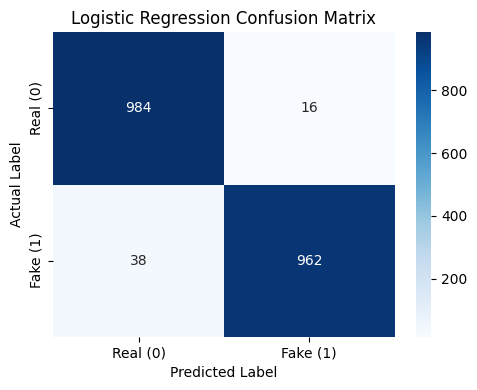

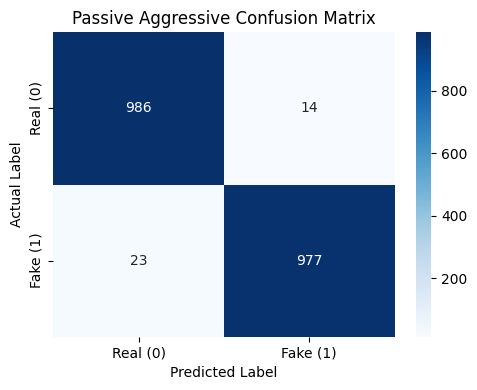

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # 1. Make predictions on the test set using both models
    lr_preds = lr_model.predict(X_test_tfidf)
    pa_preds = pa_model.predict(X_test_tfidf)

    # 2. Print accuracy metrics safely
    print("=============================================")
    print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
    print(f"Passive Aggressive Accuracy: {accuracy_score(y_test, pa_preds):.4f}")
    print("=============================================\n")

    print("--- PASSIVE AGGRESSIVE DETAILED REPORT ---")
    print(classification_report(y_test, pa_preds, target_names=['Real (0)', 'Fake (1)']))

    # 3. Create a function to display the confusion matrix
    def plot_confusion_matrix(y_true, y_pred, title):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Real (0)', 'Fake (1)'], 
                    yticklabels=['Real (0)', 'Fake (1)'])
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.title(title)
        plt.tight_layout()
        plt.show()

    # 4. Plot the confusion matrices
    print("\nGenerating Confusion Matrices...")
    plot_confusion_matrix(y_test, lr_preds, "Logistic Regression Confusion Matrix")
    plot_confusion_matrix(y_test, pa_preds, "Passive Aggressive Confusion Matrix")

except NameError as e:
    print(f"❌ NAME ERROR: {e}")
    print("This means the models (lr_model/pa_model) or test sets are not in memory. Please run your Step 5 training cell first!")
except Exception as e:
    print(f"❌ ERROR: {e}")

Export the Final Deliverables

In [29]:
import pickle

try:
    # 1. Save the trained Passive Aggressive Classifier model
    with open('fake_news_pa_model.pkl', 'wb') as model_file:
        pickle.dump(pa_model, model_file)
        
    # 2. Save the fitted TF-IDF Vectorizer 
    with open('tfidf_vectorizer.pkl', 'wb') as vec_file:
        pickle.dump(tfidf, vec_file)
        
    print("--- DELIVERABLES EXPORTED SUCCESSFULLY ---")
    print("1. Saved 'fake_news_pa_model.pkl' (Trained Classifier)")
    print("2. Saved 'tfidf_vectorizer.pkl' (Text Feature Extractor)")
    print("\nCheck your VS Code folder sidebar — you will see these files right next to your notebook!")

except Exception as e:
    print(f"❌ ERROR SAVING DELIVERABLES: {e}")

--- DELIVERABLES EXPORTED SUCCESSFULLY ---
1. Saved 'fake_news_pa_model.pkl' (Trained Classifier)
2. Saved 'tfidf_vectorizer.pkl' (Text Feature Extractor)

Check your VS Code folder sidebar — you will see these files right next to your notebook!


In [30]:
import pickle
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# 1. Define the exact same text cleaning function
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_input_text(text):
    if not isinstance(text, str):
        return ""
    # Remove punctuation, lower case, split, remove stopwords, and stem
    text = re.sub('[^a-zA-Z]', ' ', text.lower())
    words = text.split()
    cleaned_words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(cleaned_words)

# 2. Load the saved model and vectorizer from your folder
try:
    with open('fake_news_pa_model.pkl', 'rb') as model_file:
        loaded_model = pickle.load(model_file)
        
    with open('tfidf_vectorizer.pkl', 'rb') as vec_file:
        loaded_vectorizer = pickle.load(vec_file)
        
    print("🚀 Model and Vectorizer loaded successfully!")
    print("Ready to test custom news articles.\n")
    
except FileNotFoundError:
    print("❌ Error: Could not find the saved files. Please make sure you successfully ran Step 7.")

# 3. Create the test function
def predict_news(title, text):
    # Combine title and text exactly like we did in training
    full_text = str(title) + " " + str(text)
    
    # Preprocess the new text
    cleaned = clean_input_text(full_text)
    
    # Vectorize using the loaded TF-IDF vocabulary
    vectorized = loaded_vectorizer.transform([cleaned])
    
    # Make the prediction
    prediction = loaded_model.predict(vectorized)[0]
    
    # Output the result
    print("=========================================")
    print(f"ARTICLE TITLE: {title}")
    print("=========================================")
    if prediction == 1:
        print("🚨 PREDICTION RESULT: [ FAKE NEWS ] 🚨")
        print("Analysis: The language patterns match data found in the fake news collection.")
    else:
        print("✅ PREDICTION RESULT: [ REAL / TRUE NEWS ] ✅")
        print("Analysis: The vocabulary structure aligns with verified real news formatting.")
    print("=========================================\n")

🚀 Model and Vectorizer loaded successfully!
Ready to test custom news articles.



c:\Users\chand\OneDrive\Desktop\DATA ANALYTICS INTERNSHIP\Fake_News_Detection\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Example Test 1 (Testing a clear fake headline):

In [31]:
# Copy/Paste a news article to test it
custom_title = "BREAKING: Secret Alien Spacecraft Landed in Central Park This Morning"
custom_text = "Officials are panicking as a massive unidentified flying object touched down in New York. Sources say the government is trying to hide the truth from the public."

predict_news(custom_title, custom_text)

ARTICLE TITLE: BREAKING: Secret Alien Spacecraft Landed in Central Park This Morning
🚨 PREDICTION RESULT: [ FAKE NEWS ] 🚨
Analysis: The language patterns match data found in the fake news collection.



Example Test 2 (Testing standard news formatting):

In [32]:
custom_title = "Global Markets Steady as Inflation Rates Show Gradual Decline"
custom_text = "The Federal Reserve reported a minor decrease in core inflation metrics this quarter. Economic analysts suggest that corporate spending patterns are adjusting to steady interest benchmarks established earlier this year."

predict_news(custom_title, custom_text)

ARTICLE TITLE: Global Markets Steady as Inflation Rates Show Gradual Decline
✅ PREDICTION RESULT: [ REAL / TRUE NEWS ] ✅
Analysis: The vocabulary structure aligns with verified real news formatting.

